In [207]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import math

In [208]:
folderpath="toricelli data/1:8inchnozzle/27_inch_height"

In [209]:
import numpy as np

def running_slope(time, height, window=5):
    """
    Compute a smoothed derivative dh/dt using a centered rolling
    linear fit over 'window' points.
    
    window must be odd.
    """
    if window % 2 == 0:
        raise ValueError("window must be odd")
    
    n = len(height)
    half = window // 2
    slopes = np.full(n, np.nan)
    
    for i in range(half, n - half):
        t_local = time[i-half:i+half+1]
        h_local = height[i-half:i+half+1]
        
        # fit h = m t + b
        m, b = np.polyfit(t_local, h_local, 1)
        slopes[i] = m
    
    return slopes

In [210]:
start_height=27 # initial height of the liquid in inches
radius_nozzle=1/16 # radius of nozzle in inches
radius_tube=2.625/2 # radius of tube in inches. 2.66/2 inches
nozzle_area=(np.pi)*radius_nozzle**2
tube_area=(np.pi)*radius_tube**2
g=386.09 # gravity acceleration 
def ana_height(t,h_ini):
    h = (np.sqrt(h_ini) - (nozzle_area * t)*np.sqrt(2*g)/(2*tube_area))**2
    return h
#fitted_height=(np.sqrt(initial_height) - (nozzle_area * t)*np.sqrt(2*g)/(2*tube_area))**2

x=1
for filename in os.listdir(folderpath):
    filepath = os.path.join(folderpath, filename)
    df = pd.read_csv(filepath, encoding="utf-16")
    height = df[["Liquid_Height_Ranging", "Time"]]
    height["Time"]

    starting_height = height["Liquid_Height_Ranging"].iloc[:5].median()

    start_pos_ind = np.where(height["Liquid_Height_Ranging"] < starting_height - 0.05)[0][0]

    height_aligned = height.iloc[start_pos_ind:].reset_index(drop=True)
    time = pd.to_datetime(height_aligned["Time"],format="%H:%M:%S:%f")

    height_aligned["Time_seconds"] = (time - time.iloc[0]).dt.total_seconds()

    print(height_aligned)
    
    t_fit = height_aligned["Time_seconds"].to_numpy()
    h_fit = height_aligned["Liquid_Height_Ranging"].to_numpy()
    fit_line = np.polyval(np.polyfit(t_fit, h_fit, 2), t_fit)
    r2 = 1 - np.sum((h_fit - fit_line)**2) / np.sum((h_fit - h_fit.mean())**2)

    height_theoretical=ana_height(height_aligned["Time_seconds"],height_aligned["Liquid_Height_Ranging"].iloc[0])
    theoretical_exit_velocity_array=np.sqrt(2*g*height_theoretical) 
    actual_heights_array=height_aligned["Liquid_Height_Ranging"]
    time_array = height_aligned["Time_seconds"].to_numpy()
    actual_heights_array = height_aligned["Liquid_Height_Ranging"].to_numpy()
    dhdt_smooth = running_slope(time_array, actual_heights_array, window=5)
    experimental_exit_velocity_array = -(tube_area / nozzle_area) * dhdt_smooth
    #experimental_exit_velocity_array=np.sqrt(2*g*actual_heights_array)
    time_array=height_aligned["Time_seconds"]
    
    
    
    
    t_v = np.asarray(time_array, float)
    
    t_v = np.asarray(time_array, float)
    v_v = np.asarray(experimental_exit_velocity_array, float)
    ok = np.isfinite(v_v)
    coef_v = np.polyfit(t_v[ok], v_v[ok], 1)
    fit_v = np.polyval(coef_v, t_v[ok])
    r2_v = 1 - np.sum((v_v[ok] - fit_v)**2) / np.sum((v_v[ok] - v_v[ok].mean())**2)
    
    # Find indices where the aligned height is less than or equal to 0
    zero_crossings = np.where(height_aligned["Liquid_Height_Ranging"] <= 0.1)[0]
    
    # Check if it actually reached zero before extracting
    if zero_crossings.size > 0:
        first_idx = zero_crossings[0]
        exact_time = height_aligned["Time_seconds"].iloc[first_idx]
        print(f"Trial {x}: Experimental Drain Time {exact_time:.2f} seconds (Index: {first_idx})")
    else:
        print(f"Trial {x}: Liquid never reached 0 in this dataset.")

    x+=1


     Liquid_Height_Ranging         Time  Time_seconds
0                   27.022  15:24:40:27          0.00
1                   26.775  15:24:41:30          1.03
2                   26.393  15:24:42:33          2.06
3                   26.137  15:24:43:27          3.00
4                   25.760  15:24:44:32          4.05
..                     ...          ...           ...
156                 -0.216  15:27:16:65        156.38
157                 -0.216  15:27:17:65        157.38
158                 -0.216  15:27:18:65        158.38
159                 -0.213  15:27:19:65        159.38
160                 -0.213  15:27:20:65        160.38

[161 rows x 3 columns]
Trial 1: Experimental Drain Time 149.34 seconds (Index: 149)
     Liquid_Height_Ranging         Time  Time_seconds
0                   27.036  15:30:16:41          0.00
1                   26.775  15:30:17:44          1.03
2                   26.402  15:30:18:47          2.06
3                   26.346  15:30:19:41          3.

In [211]:







h_ini=18
t=np.linspace(0,140,1000)
heights_theor_tofindnull=ana_height(t,18)

In [212]:
idx=np.where(height_theoretical <= 0.1)[0]
height_aligned["Time_seconds"].iloc[idx]

155    155.71
156    156.63
157    157.63
158    158.65
159    159.66
160    160.66
161    161.66
162    162.66
163    163.66
164    164.66
165    165.66
166    166.71
Name: Time_seconds, dtype: float64

<ipython-input-213-62dff671bb03>:53: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  fig1.savefig("figures/Height27.1.8.png", dpi=300, bbox_inches="tight")
<ipython-input-213-62dff671bb03>:53: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  fig1.savefig("figures/Height27.1.8.png", dpi=300, bbox_inches="tight")
<ipython-input-213-62dff671bb03>:54: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  fig2.savefig("figures/Velocity27.1.8.png", dpi=300, bbox_inches="tight")
<ipython-input-213-62dff671bb03>:54: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  fig2.savefig("figures/Velocity27.1.8.png", dpi=300, bbox_inches="tight")


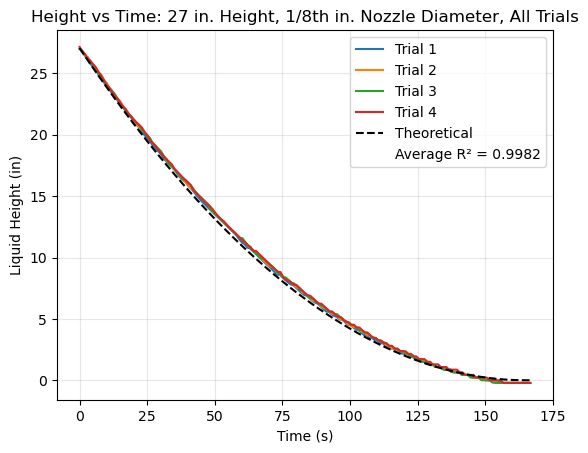

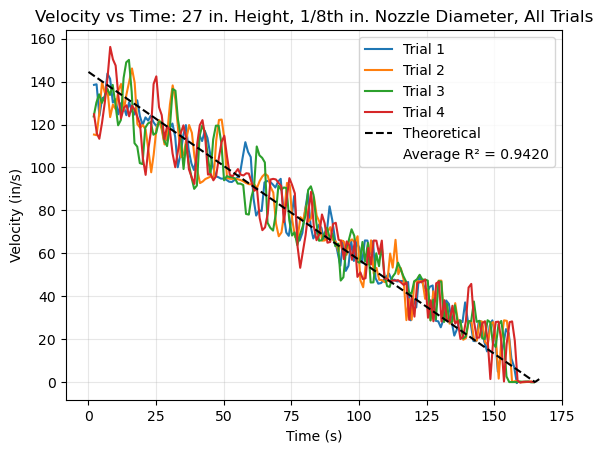

In [213]:
trials = []
for filename in sorted(os.listdir(folderpath)):
    df = pd.read_csv(os.path.join(folderpath, filename), encoding="utf-16")
    height = df[["Liquid_Height_Ranging", "Time"]]
    start_h = height["Liquid_Height_Ranging"].iloc[:5].median()
    i0 = np.where(height["Liquid_Height_Ranging"] < start_h - 0.05)[0][0]
    ha = height.iloc[i0:].reset_index(drop=True).copy()
    tt = pd.to_datetime(ha["Time"], format="%H:%M:%S:%f")
    t = (tt - tt.iloc[0]).dt.total_seconds().to_numpy()
    h = ha["Liquid_Height_Ranging"].to_numpy()
    v = -(tube_area / nozzle_area) * running_slope(t, h, window=5)
    trials.append((t, h, v))


# one theoretical line, using the average starting height and longest time
h0 = np.mean([h[0] for t, h, v in trials])
t_th = np.linspace(0, max(t.max() for t, h, v in trials), 500)
h_th = ana_height(t_th, h0)
v_th = np.sqrt(2 * g * h_th)

T_end = 2 * tube_area * np.sqrt(h0) / (nozzle_area * np.sqrt(2 * g))   # theoretical drain time

def r2_vs_theory(t, y, y_th):
    ok = np.isfinite(y) & (t <= T_end)    # only compare while the theory is still draining
    return 1 - np.sum((y[ok] - y_th[ok])**2) / np.sum((y[ok] - y[ok].mean())**2)

r2_h_list = [r2_vs_theory(t, h, ana_height(t, h0)) for t, h, v in trials]
r2_v_list = [r2_vs_theory(t, v, np.sqrt(2 * g * ana_height(t, h0))) for t, h, v in trials]
r2_h, r2_v = np.mean(r2_h_list), np.mean(r2_v_list)

# ---- Height plot ----
fig1 = plt.figure()
for n, (t, h, v) in enumerate(trials, 1):
    plt.plot(t, h, label=f"Trial {n}")
plt.plot(t_th, h_th, "k--", label="Theoretical")
plt.plot([], [], " ", label=f"Average R² = {r2_h:.4f}")
plt.title("Height vs Time: 27 in. Height, 1/8th in. Nozzle Diameter, All Trials")
plt.xlabel("Time (s)"); plt.ylabel("Liquid Height (in)")
plt.grid(alpha=0.3); plt.legend()

# ---- Velocity plot ----
fig2 = plt.figure()
for n, (t, h, v) in enumerate(trials, 1):
    plt.plot(t, v, label=f"Trial {n}")
plt.plot(t_th, v_th, "k--", label="Theoretical")
plt.plot([], [], " ", label=f"Average R² = {r2_v:.4f}")
plt.title("Velocity vs Time: 27 in. Height, 1/8th in. Nozzle Diameter, All Trials")
plt.xlabel("Time (s)"); plt.ylabel("Velocity (in/s)")
plt.grid(alpha=0.3); plt.legend()

# ---- Save ----
os.makedirs("figures", exist_ok=True)
fig1.savefig("figures/Height27.1.8.png", dpi=300, bbox_inches="tight")
fig2.savefig("figures/Velocity27.1.8.png", dpi=300, bbox_inches="tight")
plt.show()